<a href="https://colab.research.google.com/github/iannickgagnon/sagedays_iannick_2026/blob/main/python_2/laboratoire_python_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1 - Tests avec assertions (`assert`)

La fonction `trouver_valeur_minimum()` vous est fournie. Écrivez une fonction nommée `test_trouver_valeur_minimum_succes()` qui ne reçoit rien et qui valide que la valeur retournée pour la liste `[1, 2, 3, 4, 5]` est bel et bien `1`.

In [16]:
def trouver_valeur_minimum(liste: list):
  """
  Fonction à tester.

  Retourne la plus petite valeur d'une liste de valeurs numériques.
  """
  return min(liste)

In [17]:
"""
ÉCRIVEZ VOTRE RÉPONSE ICI.
"""
def test_trouver_valeur_minimum_succes():
  assert trouver_valeur_minimum([1, 2, 3, 4, 5]) == 1

In [22]:
# Exécuter le test: Il ne devrait rien se passer
test_trouver_valeur_minimum()

# 2 - Tests avec `pytest`

La fonction `assert_equal()` vous est fournie. Implémentez la fonction de `test test_assert_equal_raises()` et utilisez le gestionnaire de contexte `pytest.raises()` pour tester qu'elle lève bel et bien une erreur de type `AssertionError` lorsque les valeurs diffèrent de plus que la tolérance par défaut de `1e-6`.

Inspirez-vous du premier exemplee de la page suivante tirée de la documentation officielle: [cliquez ici](https://docs.pytest.org/en/7.1.x/how-to/assert.html#assertions-about-expected-exceptions).

**Remarque:** N'oubliez pas d'importer `pytest`.

In [23]:
from typing import Union

def assert_equal(x_obtenu: Union[int, float],
                 x_cible: Union[int, float],
                 tolerance: float = 1e-6) -> None:
  """
  Effectue un test d'égalité basé sur une tolérance.

  Args:
    x_obtenu (Union[int, float]): La valeur à tester.
    x_cible (Union[int, float]): La valeur cible.
    tolerance (Union[int, float]): La tolérance numérique.

  Retourne:
    Rien.
  """
  assert abs(x_obtenu - x_cible) <= tolerance, 'Les valeurs ne sont pas égales'

In [24]:
"""
ÉCRIVEZ VOTRE RÉPONSE ICI.
"""

# Importer pytest
import pytest

# Implémenter le test
def test_assert_equal_raises():
  with pytest.raises(AssertionError):
    assert_equal(1, 1 + 1e-5)

In [25]:
# Exécuter le test: Il ne devrait rien se passer
test_assert_equal_raises()

# 3 - Exceptions

Ajoutez un test d'espèce à la fonction `trouver_valeur_minimum()` ci-dessous en utilisant la fonction native `isinstance(objet, type)`. Validez qu'il s'agit d'une liste (`list`) et levez (`raise`) une erreur de type `TypeError` avec un message approprié si ce n'est pas le cas.

## EXEMPLE
```shell
>>> isinstance(1, int)
True
>>> isinstance(1, float)
False
>>> isinstance(1 + 1.0, float)
True
```

In [1]:
def trouver_valeur_minimum(liste: list):
  """
  Fonction à tester.

  Retourne la plus petite valeur d'une liste de valeurs numériques.
  """

  # Valider qu'il s'agit d'une liste
  if not isinstance(liste, list):
    raise TypeError("L'argument 'liste' doit être un une instance du type list")

  return min(liste)

In [14]:
# Exemple d'appel sans ereur
trouver_valeur_minimum([1, 2, 3, 4, 5])

1

In [15]:
# Exemple d'appel avec un tuple
trouver_valeur_minimum((1, 2, 3, 4, 5))

TypeError: L'argument 'liste' doit être un une instance du type list

# 3.1 - Validations chaînées

Validez aussi que les éléments de la liste sont des tous entiers (`int`).

In [2]:
"""
RECOPIEZ LA FONCTION PRÉCÉEDENTE ICI.
"""

def trouver_valeur_minimum(liste: list):
  """
  Fonction à tester.

  Retourne la plus petite valeur d'une liste de valeurs numériques.
  """

  # Valider qu'il s'agit d'une liste
  if not isinstance(liste, list):
    raise TypeError("L'argument 'liste' doit être un une instance du type list")

  # Valider que les éléments sont tous des entiers
  for valeur in liste:
    if not isinstance(valeur, int):
      raise TypeError('La liste ne doit contenir que des entiers.')

  return min(liste)

In [11]:
# Exemple d'appel sans ereur
trouver_valeur_minimum([1, 2, 3, 4, 5])

1

In [12]:
# Exemple d'appel avec un tuple
trouver_valeur_minimum((1, 2, 3, 4, 5))

TypeError: L'argument 'liste' doit être un une instance du type list

In [13]:
# Exemple d'appel avec un rationnel
trouver_valeur_minimum([1, 2, 3, 4, 5.0])

TypeError: La liste ne doit contenir que des entiers.

# 3.2 - Évaluations simultanées (`all`)

Refactorisez la partie du code qui valide que les valeurs contenues dans la liste sont des entiers et retirez la boucle en utilisant (1) une compréhension de liste et (2) la fonction `all()`. Voici la documentation pertinente: [cliquez ici](https://docs.python.org/3/library/functions.html#all).

1. Utilisez la compréhension pour créer une liste qui contient une série de booléens qui correspondent aux résultats des tests d'espèce des valeurs (c.-à-d. qui indiquent s'il s'agit d'entiers).

2. Enveloppez la liste créée par compréhension dans la fonction `all()` et placez le résultat dans la condition d'un bloc `if` qui lève l'exception de type `TypeError`.

## EXEMPLE
```shell
>>> all([True, True, False])
False
>>> all([True, True, True])
True
>>> liste = [1, 2, 3, 4, 5]
>>> liste_booleens = [isinstance(valeur, float) for valeur in liste]
>>> print(liste_booleens)
[False, False, False, False, False]
>>> all(liste_booleens)
False
>>> not all(liste_booleens)
True
```

<details>
  <summary>VOIR LA SOLUTION</summary>

  ```python
  def trouver_valeur_minimum(liste: list):
    """
    Fonction à tester.

    Retourne la plus petite valeur d'une liste de valeurs numériques.
    """

    # Valider qu'il s'agit d'une liste
    if not isinstance(liste, list):
      raise TypeError("L'argument 'liste' doit être un une instance du type list")

    # Valider que les éléments sont tous des entiers
    if not all([isinstance(valeur, int) for valeur in liste]):
      raise TypeError('La liste ne doit contenir que des entiers.')

    return min(liste)
  ```
</details>

In [47]:
"""
RECOPIEZ LA FONCTION PRÉCÉEDENTE ICI.
"""

def trouver_valeur_minimum(liste: list):
  """
  Fonction à tester.

  Retourne la plus petite valeur d'une liste de valeurs numériques.
  """

  # Valider qu'il s'agit d'une liste
  if not isinstance(liste, list):
    raise TypeError("L'argument 'liste' doit être un une instance du type list")

  # Valider que les éléments sont tous des entiers
  if not all([isinstance(valeur, int) for valeur in liste]):
    raise TypeError('La liste ne doit contenir que des entiers.')

  return min(liste)

In [48]:
# Exemple d'appel sans erreur
trouver_valeur_minimum([30, 0, 10, 20])

0

In [49]:
# Exemple d'appel avec erreur
trouver_valeur_minimum([30, 0, 10, 20.0])

TypeError: La liste ne doit contenir que des entiers.

# 4 - Classe: Ajouter une méthode (spéciale) à une classe existante

Considérez la classe `Polynome`.

Ajoutez une méthode publique nommée `__post_init__()` qui ne reçoit pas d'arguments supplémentaires (n'oubliez pas la référence `self`). Cette dernière ...
1. Valide que les coefficients fournir sont des nombres.
2. Calcule le degré du polynôme et l'insère dans l'attribut `degre`.

Notez qu'il est possible d'utiliser un `tuple` comme deuxième argument dans la fonction `isinstance()`:
```shell
>>> isinstance(1, (int, float))
True
>>> isinstance(1.0, (int, float))
True
>>> isinstance(True, (int, float))
False
```

**Remarque:** Les méthodes dont le nom est entouré de doubles barres de soulignement (*double underscore* ou *dunder*) ont une signification spéciale en Python. Dans le cas de `__post_init__()`, elle est exécutée après l'initialisation de d'une classe-conteneur: `dataclass`.

<details>
  <summary>VOIR LA SOLUTION</summary>

  ```python
  def __post_init__(self):
    """
    Valide que les coefficients sont des nombres et met à jour le degré du polynôme.
    """

    # Valider que les coefficients sont du bon type
    if not all([isinstance(coeff, (int, float)) for coeff in self.coefficients]):
      raise TypeError('Les coefficients doivent être des entiers ou des réels')

    # Mettre à jour le degré du polynôme
    self.degre = len(self.coefficients) - 1
  ```
</details>

In [50]:
from dataclasses import dataclass
from typing import Optional, Union


@dataclass
class Polynome:
  """
  Un polynôme de degré quelconque stocké sous forme de liste de coefficients.

  Les coefficients sont stockés en ordre croissant de puissance en partant de
  zéro:
    - coefficients[0] -> x^0
    - coefficients[1] -> x^1
    - ...
    - coefficients[n] -> x^n

  Attributs:
    coefficients (list[Union[int, float]]): Les coefficients.
    degre (Optional[int]): Le degré du polynôme. Valeur par défaut de None.
  """

  coefficients: list[Union[int, float]]
  degre: Optional[int] = None

  def evaluer(self, x: Union[int, float]) -> float:
    """
    Évalue le polynôme à la position donnée.

    Args:
      x (Union[int, float]): La position.

    Retourne:
      float: La valeur du polynôme à la position donnée.
    """
    return sum([self.coefficients[i] * x ** i for i in range(len(self.coefficients))])

  """
  ÉCRIVEZ VOTRE RÉPONSE ICI.
  """
  def __post_init__(self):
    """
    Valide que les coefficients sont des nombres et met à jour le degré du polynôme.
    """

    # Valider que les coefficients sont du bon type
    if not all([isinstance(coeff, (int, float)) for coeff in self.coefficients]):
      raise TypeError('Les coefficients doivent être des entiers ou des réels')

    # Mettre à jour le degré du polynôme
    self.degre = len(self.coefficients) - 1

In [53]:
# Créer le polynôme y = 1 + x + x^2
polynome = Polynome([1, 1, 1])

# L'inspecter (on peut voir si son degré est à jour)
print(polynome)

Polynome(coefficients=[1, 1, 1], degre=2)


# 4 - Créer sa propre classe

Créez une classe nommée `SolveurRacineBisection` qui expose des outils qui permettent de calculer les racines d'une fonction en utilisant la méthode de la bissection ([cliquez ici](https://fr.wikipedia.org/wiki/M%C3%A9thode_de_dichotomie)).

La classe doit contenir les attributs suivants:
- tolerance (float): La tolérance sur la valeur absolue de f(x). Valeur par défaut de 1e-6.
- max_iterations (int): Le nombre maximal d'itérations. Valeur par défaut de 100.

Ajoutez une méthode qui permet de calculer la racine d'un polynôme donné entre les bornes `a` et `b` dont la signature est la suivante: `resoudre(self, polynome: Polynome, a: Union[int, float], b: Union[int, float]) -> float`.

Cette dernière implémente l'algorithme suivant donné sous forme de pseudocode:
```
Algorithme bissection(f, a, b, tolerance, max_iterations)

  Si a >= b
    Signaler une erreur (ValueError)
  Fin Si

  Si f(a) = 0
    Retourner a
  Fin Si

  Si f(b) = 0
    Retourner b
  Fin Si

  Si f(a) x f(b) > 0
    Signaler une erreur (ValueError)
  Fin Si

  Pour i allant de 1 à max_iterations

    milieu ← (a + b) / 2
    f_milieu ← f(milieu)

    Si |f_milieu| <= tolerance
      Retourner milieu
    Fin Si

    Si f(a) x f_milieu < 0
      b ← milieu
    Sinon
      a ← milieu
    Fin Si

  Fin Pour

  Retourner (a + b) / 2

Fin Algorithme
```

<details>
  <summary>VOIR LA SOLUTION</summary>

  ```python
@dataclass
class SolveurRacineBisection:
    """
    Un solveur de racine utilisant la méthode de bissection.

    Attributs:
      tolerance (float): La tolérance sur la valeur absolue de f(x).
      max_iterations (int): Le nombre maximal d'itérations.
    """

    tolerance: float = 1e-6
    max_iterations: int = 100

    def resoudre(self, polynome: Polynome, a: Union[int, float], b: Union[int, float]) -> float:
        """
        Cherche une racine du polynôme dans l'intervalle [a, b].

        Args:
          polynome (Polynome): Le polynôme.
          a (Union[int, float]): La borne gauche.
          b (Union[int, float]): La borne droite.

        Retourne:
          float: Une approximation de la racine.

        Raises:
          ValueError: Si l'intervalle est invalide ou si la méthode ne peut pas être appliquée.
        """

        fa = polynome.evaluer(a)
        fb = polynome.evaluer(b)

        if a >= b:
            raise ValueError("La borne gauche doit être strictement plus petite que la borne droite.")

        if fa == 0:
            return float(a)

        if fb == 0:
            return float(b)

        if fa * fb > 0:
            raise ValueError("Le polynôme doit changer de signe sur [a, b] pour appliquer la bissection.")

        # Appliquer la bissection
        for _ in range(self.max_iterations):
            milieu = (a + b) / 2
            fm = polynome.evaluer(milieu)

            if abs(fm) <= self.tolerance:
                return float(milieu)

            if fa * fm < 0:
                b = milieu
                fb = fm
            else:
                a = milieu
                fa = fm

        return float((a + b) / 2)
  ```
</details>



In [95]:
@dataclass
class SolveurRacineBisection:
    """
    Un solveur de racine utilisant la méthode de bissection.

    Attributs:
      tolerance (float): La tolérance sur la valeur absolue de f(x). Valeur par défaut de 1e-6.
      max_iterations (int): Le nombre maximal d'itérations. Valeur par défaut de 100.
    """

    tolerance: float = 1e-6
    max_iterations: int = 100

    def resoudre(self, polynome: Polynome, a: Union[int, float], b: Union[int, float]) -> float:
        """
        Cherche une racine du polynôme dans l'intervalle [a, b].

        Args:
          polynome (Polynome): Le polynôme.
          a (Union[int, float]): La borne gauche.
          b (Union[int, float]): La borne droite.

        Retourne:
          float: Une approximation de la racine.

        Raises:
          ValueError: Si l'intervalle est invalide ou si la méthode ne peut pas être appliquée.
        """

        fa = polynome.evaluer(a)
        fb = polynome.evaluer(b)

        if a >= b:
            raise ValueError("La borne gauche doit être strictement plus petite que la borne droite.")

        if fa == 0:
            return float(a)

        if fb == 0:
            return float(b)

        if fa * fb > 0:
            raise ValueError("Le polynôme doit changer de signe sur [a, b] pour appliquer la bissection.")

        # Appliquer la bissection
        for _ in range(self.max_iterations):
            milieu = (a + b) / 2
            fm = polynome.evaluer(milieu)

            if abs(fm) <= self.tolerance:
                return float(milieu)

            if fa * fm < 0:
                b = milieu
                fb = fm
            else:
                a = milieu
                fa = fm

        return float((a + b) / 2)

In [97]:
# Initialiser un solveur avec les valeurs par défaut
solveur = SolveurRacineBisection()
print(solveur)

print()

# La racine d'une droite passant par l'origine doit être approx. x = 0
droite_par_origine = Polynome([0, 1])
print(droite_par_origine)
print(f"Racine entre -5 et 5: {solveur.resoudre(polynome=droite_par_origine,
                                                a=-5,
                                                b=5)}")

print()

# La racine de la droite y = x - 3 doit être approx. x = 3
droite_decalee = Polynome([-3, 1])
print(droite_decalee)
print(f"Racine entre -5 et 5: {solveur.resoudre(polynome=droite_decalee,
                                                a=-5,
                                                b=5)}")

print()

# La racine de la cubique 3x^3 - 7x^2 + 15x -35 doit être approx. x = 7/3 (2.3333...)
cubique = Polynome([-35, 15, -7, 3])
print(cubique)
print(f"Racine entre -5 et 5: {solveur.resoudre(polynome=cubique,
                                                a=-5,
                                                b=5)}")

SolveurRacineBisection(tolerance=1e-06, max_iterations=100)

Polynome(coefficients=[0, 1], degre=1)
Racine entre -5 et 5: 0.0

Polynome(coefficients=[-3, 1], degre=1)
Racine entre -5 et 5: 2.999999523162842

Polynome(coefficients=[-35, 15, -7, 3], degre=3)
Racine entre -5 et 5: 2.333333343267441


# 4 - Persistence

Pour l'exercice qui suit, consultez les derniers exemples de `carnet_python_2.ipynb` [cliquez ici](https://github.com/iannickgagnon/sagedays_iannick_2026/blob/main/python_2/carnet_python_2.ipynb).

## 4.1 - Sauvegarder la configuration du solveur

Ajoutez une méthode publique nommée `sauvegarder()` qui reçoit une chaîne de caractères qui correspond à un nom de fichier avec l'extension `.yaml`. La méthode sérialise la configuration du solveur dans un fichier tel que `configuration.yaml`:
```
tolerance: 1e-06
max_iterations: 100
```
Assurez-vous que le nom du fichier contient l'extension en utilisant la méthode `str.endswith()`. Si l'extension n'est pas la bonne, levez une erreur de type `ValueError` avec un message approprié.

<details>
  <summary>VOIR LA SOLUTION</summary>

  ```python
  def sauvegarder(self, nom_fichier: str) -> None:
    """
    Sauvegarde la configuration du solveur en format YAML.

    Args:
      nom_fichier (str): Le nom du fichier.

    Retourne:
      Rien.
    """

    # Valider l'extension du fichier
    if not nom_fichier.endswith('.yaml'):
      raise ValueError("Le nom du fichier doit posséder l'extension .yaml")

    # Ouvrir le fichier en mode écriture et y insérer les deux paramètres
    with open(nom_fichier, 'w') as fichier:
      fichier.write(f'tolerance: {self.tolerance}\n')
      fichier.write(f'max_iterations: {self.max_iterations}')
  ```
</details>

## 4.2 - Charger une configuration à partir d'un fichier YAML

Ajoutez une méthode publique nommée `charger()` qui reçoit une chaîne de caractères qui correspond à un nom de fichier avec l'extension `.yaml`. La méthode charge la configuration en utilisant la fonction `safe_load()` de la librairie `yaml`.

<details>
  <summary>VOIR LA SOLUTION</summary>
  ```python
  def charger(self, nom_fichier: str) -> None:
    """
    Charge une configuration à partir d'un fichier YAML.

    Args:
      nom_fichier (str): Le nom du fichier YAML.

    Retourne:
      Rien.
    """

    # Ouvrir le fichier en mode lecture et lire les données
    with open(nom_fichier, 'r') as fichier:
      options: dict = yaml.safe_load(fichier)
    
    # Mettre à jour la configuration
    self.tolerance = options['tolerance']
    self.max_iterations = options['max_iterations']
  ```
</details>

In [121]:
from dataclasses import dataclass
import yaml

@dataclass
class SolveurRacineBisection:
  """
  Un solveur de racine utilisant la méthode de bissection.

  Attributs:
    tolerance (float): La tolérance sur la valeur absolue de f(x). Valeur par défaut de 0.000001.
    max_iterations (int): Le nombre maximal d'itérations. Valeur par défaut de 100.
  """

  tolerance: float = 0.000001
  max_iterations: int = 100

  """
  ÉCRIVEZ VOTRE RÉPONSE ICI.
  """
  def sauvegarder(self, nom_fichier: str) -> None:
    """
    Sauvegarde la configuration du solveur en format YAML.

    Args:
      nom_fichier (str): Le nom du fichier.

    Retourne:
      Rien.
    """

    # Valider l'extension du fichier
    if not nom_fichier.endswith('.yaml'):
      raise ValueError("Le nom du fichier doit posséder l'extension .yaml")

    # Ouvrir le fichier en mode écriture et y insérer les deux paramètres
    with open(nom_fichier, 'w') as fichier:
      fichier.write(f'tolerance: {self.tolerance}\n')
      fichier.write(f'max_iterations: {self.max_iterations}')

  """
  ÉCRIVEZ VOTRE RÉPONSE ICI.
  """
  def charger(self, nom_fichier: str) -> None:
    """
    Charge une configuration à partir d'un fichier YAML.

    Args:
      nom_fichier (str): Le nom du fichier YAML.

    Retourne:
      Rien.
    """

    # Ouvrir le fichier en mode lecture et lire les données
    with open(nom_fichier, 'r') as fichier:
      options: dict = yaml.safe_load(fichier)

    # Mettre à jour la configuration
    self.tolerance = float(options['tolerance'])
    self.max_iterations = int(options['max_iterations'])

In [110]:
# Le nom du fichier de sauvegarde/chargement
NOM_FICHIER_YAML: str = 'solveur.yaml'

# Initialiser un solveur avec les paramètres par défaut
solveur = SolveurRacineBisection()
print(solveur)

# Sauvegarder
solveur.sauvegarder(NOM_FICHIER_YAML)

SolveurRacineBisection(tolerance=1e-06, max_iterations=100)


## Avant d'exécuter la cellule suivante, modifiez les paramètres dans `solveur.yaml` afin d'observer que le chargement est bien effectué.

In [118]:
# Charger la nouvelle configuration et afficher
solveur.charger(NOM_FICHIER_YAML)
print(solveur)

{'tolerance': '1e-06', 'max_iterations': 125}
SolveurRacineBisection(tolerance=1e-06, max_iterations=125)


# 5 - Graphiques

Complétez la méthode `tracer_solution()` en vous inspirant des indices dans les commentaires.

Voici les références pertinentes dans la documentation:
- [plt.scatter](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html)
- [plt.plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html)
- [plt.title](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.title.html)
- [plt.xlabel](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.xlabel.html)
- [plt.ylabel](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.ylabel.html)
- [plt.xlim](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.xlim.html)
- [plt.grid](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.grid.html)



In [151]:
# Importez l'interface pyplot de la librairie matplotblib
import matplotlib.pyplot as plt

@dataclass
class SolveurRacineBisection:
  """
  Un solveur de racine utilisant la méthode de bissection.

  Attributs:
    tolerance (float): La tolérance sur la valeur absolue de f(x). Valeur par défaut de 1e-6.
    max_iterations (int): Le nombre maximal d'itérations. Valeur par défaut de 100.
  """

  tolerance: float = 1e-6
  max_iterations: int = 100

  def resoudre(self, polynome: Polynome, a: Union[int, float], b: Union[int, float]) -> float:
      """
      Cherche une racine du polynôme dans l'intervalle [a, b].

      Args:
        polynome (Polynome): Le polynôme.
        a (Union[int, float]): La borne gauche.
        b (Union[int, float]): La borne droite.

      Retourne:
        float: Une approximation de la racine.

      Raises:
        ValueError: Si l'intervalle est invalide ou si la méthode ne peut pas être appliquée.
      """

      fa = polynome.evaluer(a)
      fb = polynome.evaluer(b)

      if a >= b:
          raise ValueError("La borne gauche doit être strictement plus petite que la borne droite.")

      if fa == 0:
          return float(a)

      if fb == 0:
          return float(b)

      if fa * fb > 0:
          raise ValueError("Le polynôme doit changer de signe sur [a, b] pour appliquer la bissection.")

      # Appliquer la bissection
      for _ in range(self.max_iterations):
          milieu = (a + b) / 2
          fm = polynome.evaluer(milieu)

          if abs(fm) <= self.tolerance:
              return float(milieu)

          if fa * fm < 0:
              b = milieu
              fb = fm
          else:
              a = milieu
              fa = fm

      return float((a + b) / 2)

  def tracer_solution(self, polynome: Polynome, a: Union[int, float], b: Union[int, float], n_pts: int = 100) -> None:
    """
    Trace la solution trouvée par le solveur superposée au polynôme.

    Args:
      polynome (Polynome): Le polynôme à résoudre et traqcer.
      a (Union[int, float]): La borne gauche.
      b (Union[int, float]): La borne droite.
      n_pts (int, optionnel): Nombre de points à tracer entre a et b inclusivement. Valeur par défaut de 100.

    Retourne:
      Rien.
    """

    # Créer les vecteurs x = [r] et y = [0] pour tracer la racine
    x_racine: list[float] = [self.resoudre(polynome=polynome, a=a, b=b)]
    y_racine: list[float] = [0.0]

    # Créer les vecteurs x = [a, a + delta, ..., b - delta, b] et y = [f(x[0]), f(x[1]), ..., f(x[n - 1])]
    delta = (b - a) / (n_pts)
    x = [a + i * delta for i in range(n_pts)]
    y = [polynome.evaluer(x_i) for x_i in x]

    # Tracer un point rouge pour la racine (plt.scatter)
    plt.scatter(x_racine, y_racine, color='r')

    # Tracer le polynôme (plt.plot)
    plt.plot(x, y, color='k')

    # Ajouter un titre (plt.title)
    plt.title('Racine du polynôme')

    # Nommer les axes (plt.xlabel, plt.ylabel)
    plt.xlabel('x')
    plt.ylabel('f(x)')

    # Limiter l'axe horizontal entre 'a' et 'b' (plt.xlim)
    plt.xlim((a, b))

    # Ajouter une grille (plt.grid)
    plt.grid()

    # Afficher le graphique (plt.show)
    plt.show()

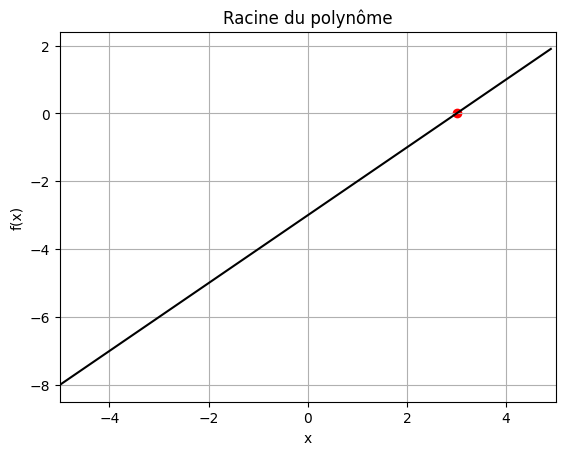

In [152]:
# Initialiser le solveur
solveur = SolveurRacineBisection()

# Initialiser le polynôme y = x - 3
polynome = Polynome([-3, 1])

# Tracer la solution
solveur.tracer_solution(polynome=polynome,
                        a=-5,
                        b=5)